#Clustering
## Definición de Polígonos Comerciales (Clustering Espacial)

**Objetivo:** Identificar las fronteras físicas de las zonas comerciales en el sur de la CDMX basándonos **únicamente en la densidad geográfica** (latitud y longitud), aislando temporalmente las variables económicas.

### Justificación del Algoritmo y Métrica

* **DBSCAN (Density-Based Spatial Clustering of Applications with Noise):** A diferencia de K-Means (que fuerza clusters esféricos), DBSCAN agrupa por densidad contigua. Esto es ideal para el urbanismo, ya que permite detectar corredores comerciales irregulares (ej. negocios a lo largo de una avenida) y aislar el "ruido" (negocios solitarios en zonas puramente residenciales).
* **Métrica Haversine:** Para evitar las distorsiones de la distancia Euclidiana plana, se transforman las coordenadas a radianes y se aplica la fórmula Haversine, garantizando un cálculo geográfico exacto sobre la curvatura de la Tierra.

### Parámetros del Modelo Espacial

Para este primer acercamiento, establecemos las siguientes reglas de vecindad:
1. **Radio de búsqueda ($\epsilon$):** 120 metros (aproximadamente la longitud de una cuadra grande).
2. **Densidad mínima (`min_samples`):** 20 negocios. Si no hay al menos 20 establecimientos dentro del radio, los puntos se clasifican como ruido (Cluster `-1`).

Cargando el dataset final limpio...
Dataset cargado con 20748 registros y 17 columnas.

Convirtiendo coordenadas a radianes para cálculo GPS...
Entrenando DBSCAN Espacial (Radio: 120m, Mínimo: 20 negocios)...

RESULTADOS
Polígonos comerciales detectados (Zonas): 148
Negocios aislados (Ruido fuera de zonas densas): 6732 (32.45%)


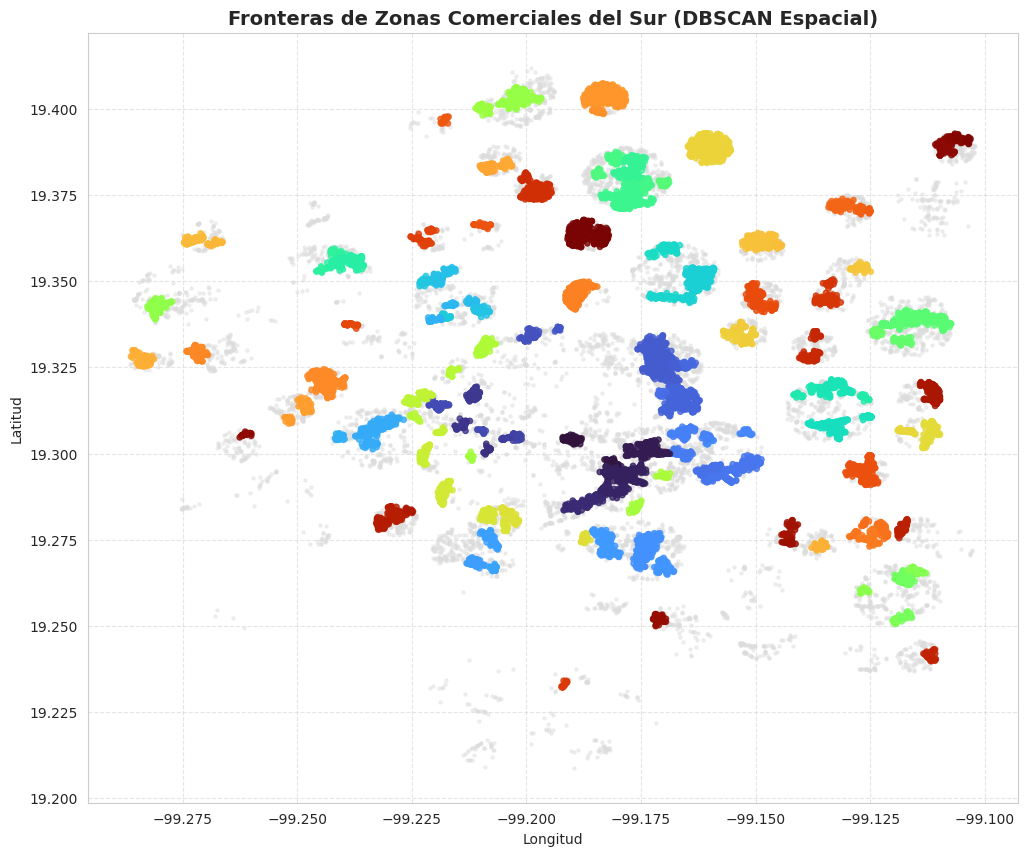

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN

# Carga de datos limpios
print("Cargando el dataset final limpio...")
df = pd.read_csv('dataset_cdmx_limpio.csv')
print(f"Dataset cargado con {df.shape[0]} registros y {df.shape[1]} columnas.\n")

# Para usar la distancia Haversine (geodesia), las coordenadas deben estar en radianes
print("Convirtiendo coordenadas a radianes para cálculo GPS...")
coords_rad = np.radians(df[['latitud', 'longitud']])

# Ajustamos un radio de 120 metros a la redonda y un umbral mínimo de 20 negocios juntos
RADIO_METROS = 120
EPSILON = RADIO_METROS / 6371000.0  # Conversión matemática a radianes (Radio de la Tierra = 6,371 km)
MIN_NEGOCIOS = 20                   # Densidad mínima para considerar que es un núcleo comercial

print(f"Entrenando DBSCAN Espacial (Radio: {RADIO_METROS}m, Mínimo: {MIN_NEGOCIOS} negocios)...")

# Entrenamiento
dbscan_espacial = DBSCAN(eps=EPSILON, min_samples=MIN_NEGOCIOS, metric='haversine', algorithm='ball_tree')
df['cluster_espacial'] = dbscan_espacial.fit_predict(coords_rad)

# Metricas de evaluación
# El algoritmo etiqueta como -1 a los negocios aislados (ruido residencial)
total_clusters = len(set(df['cluster_espacial'])) - (1 if -1 in df['cluster_espacial'].values else 0)
total_ruido = list(df['cluster_espacial']).count(-1)
porcentaje_ruido = (total_ruido / len(df)) * 100

print("\nRESULTADOS")
print(f"Polígonos comerciales detectados (Zonas): {total_clusters}")
print(f"Negocios aislados (Ruido fuera de zonas densas): {total_ruido} ({porcentaje_ruido:.2f}%)")

# Visualizaión fronteras espaciales
plt.figure(figsize=(12, 10))
sns.set_style("whitegrid")

# Dibujamos el ruido en gris muy claro para enfocarnos en los núcleos comerciales
ruido = df[df['cluster_espacial'] == -1]
plt.scatter(ruido['longitud'], ruido['latitud'], c='gainsboro', s=5, alpha=0.4, label='Zona Residencial / Aislados')

# Dibujamos las zonas comerciales densas con una paleta de colores contrastantes
zonas_densas = df[df['cluster_espacial'] != -1]
plt.scatter(zonas_densas['longitud'], zonas_densas['latitud'],
            c=zonas_densas['cluster_espacial'], cmap='turbo', s=15, alpha=0.8)

plt.title('Fronteras de Zonas Comerciales del Sur (DBSCAN Espacial)', fontsize=14, fontweight='bold')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Perfilamiento Económico y Vocación de Zonas

**Objetivo:** Transicionar de un clustering puramente geográfico a una matriz analítica multivariada. Por cada uno de los polígonos detectados, calcularemos su densidad, su nivel de consolidación (tráfico y rating), su salud económica (tasa de supervivencia) y su tipo de comercio principal utilizando las variables categóricas codificadas.

In [2]:
import pandas as pd

print("Extrayendo el perfil económico de las 148 zonas comerciales...")

# Filtramos el ruido (zonas en gris).
df_zonas = df[df['cluster_espacial'] != -1].copy()

# Agrupación Base
# - Total de negocios: Para medir la competencia.
# - Rating promedio: Nivel de satisfacción de la zona.
# - Tráfico total: Suma de user_ratings_total (proxy de afluencia peatonal/clientes).
# - Tasa de actividad: Como estatus activo es 1 y cerrado es 0, la media nos da el % de supervivencia.
perfil_clusters = df_zonas.groupby('cluster_espacial').agg(
    total_negocios=('place_id', 'count'),
    rating_promedio=('rating', 'mean'),
    trafico_total=('user_ratings_total', 'sum'),
    tasa_actividad=('id_estatus', 'mean')
).reset_index()

# Agrupación de sectores comerciales
# Sumamos las columnas binarias del One-Hot Encoding para saber de qué trata la zona
cols_sectores = [col for col in df_zonas.columns if col.startswith('sector_')]
perfil_sectores = df_zonas.groupby('cluster_espacial')[cols_sectores].sum().reset_index()

# Fusión de la Matriz de Recomendación
df_perfil_final = pd.merge(perfil_clusters, perfil_sectores, on='cluster_espacial')

# Limpieza estética de los números
df_perfil_final['rating_promedio'] = df_perfil_final['rating_promedio'].round(2)
df_perfil_final['tasa_actividad'] = (df_perfil_final['tasa_actividad'] * 100).round(1) # Lo pasamos a porcentaje real

print(f"Matriz de Perfilamiento completada. Tenemos {len(df_perfil_final)} zonas perfiladas.")
print("\nTOP 5 ZONAS CON MAYOR TRÁFICO (Afluencia de clientes):")
print(df_perfil_final.sort_values(by='trafico_total', ascending=False).head(5).to_string())

Extrayendo el perfil económico de las 148 zonas comerciales...
Matriz de Perfilamiento completada. Tenemos 148 zonas perfiladas.

TOP 5 ZONAS CON MAYOR TRÁFICO (Afluencia de clientes):
     cluster_espacial  total_negocios  rating_promedio  trafico_total  tasa_actividad  sector_1  sector_2  sector_3  sector_4  sector_5  sector_6  sector_7
42                 42             376             4.08         419832            89.6       127        94        51        13        15        30        46
57                 57             352             4.09         300182            90.6        64       103        81        12        25        25        42
0                   0             179             4.02         283871            97.8        57       100         6         1        14         1         0
98                 98             218             3.95         195294            91.7        64       110        21         0        20         0         3
120               120             2

## Motor de Reglas de Negocio (Recomendador)

In [3]:
import pandas as pd
import numpy as np

print("Iniciando Motor de Recomendaciones de Inversión...")

nombres_sectores = {
    'sector_1': 'Alimentos y Bebidas',
    'sector_2': 'Retail y Conveniencia',
    'sector_3': 'Salud y Bienestar',
    'sector_4': 'Entretenimiento',
    'sector_5': 'Finanzas y Servicios',
    'sector_6': 'Educación',
    'sector_7': 'Servicios y Mantenimiento'
}

recomendaciones = []

for index, zona in df_perfil_final.iterrows():
    id_zona = int(zona['cluster_espacial'])
    trafico = zona['trafico_total']
    actividad = zona['tasa_actividad']
    total_locales = zona['total_negocios']

    # Alerta de Riesgo (Ajustado al 80% de supervivencia)
    if actividad < 80.0:
        recomendaciones.append({
            'Cluster': id_zona,
            'Locales_Totales': total_locales,
            'Tráfico_Peatonal': trafico,
            'Diagnóstico': 'RIESGO (Alta Rotación)',
            'Recomendación': f'Evitar. El {100-actividad:.1f}% de los locales han cerrado.'
        })
        continue

    # Análisis de Saturación vs Oportunidad
    if trafico > 5000:
        sectores_presentes = {}
        for col in nombres_sectores.keys():
            if col in zona.index:
                sectores_presentes[nombres_sectores[col]] = zona[col]

        # Sector dominante
        sector_dominante = max(sectores_presentes, key=sectores_presentes.get)
        porcentaje_dominio = (sectores_presentes[sector_dominante] / total_locales) * 100

        # Sectores que representan menos del 5% de la oferta local
        huecos = [sec for sec, cantidad in sectores_presentes.items() if (cantidad / total_locales) < 0.05]

        if huecos:
            txt_huecos = ", ".join(huecos)
            recomendaciones.append({
                'Cluster': id_zona,
                'Locales_Totales': total_locales,
                'Tráfico_Peatonal': trafico,
                'Diagnóstico': 'OPORTUNIDAD',
                'Recomendación': f'Déficit detectado (<5% de oferta) en: {txt_huecos}.'
            })
        elif porcentaje_dominio > 50:
            recomendaciones.append({
                'Cluster': id_zona,
                'Locales_Totales': total_locales,
                'Tráfico_Peatonal': trafico,
                'Diagnóstico': 'MERCADO SATURADO',
                'Recomendación': f'El {porcentaje_dominio:.1f}% es {sector_dominante}. Altísima competencia.'
            })
        else:
             recomendaciones.append({
                'Cluster': id_zona,
                'Locales_Totales': total_locales,
                'Tráfico_Peatonal': trafico,
                'Diagnóstico': 'ZONA DIVERSA',
                'Recomendación': 'Ecosistema comercial sano y equilibrado.'
            })

df_diagnostico = pd.DataFrame(recomendaciones)

print(f"Motor ejecutado. Diagnósticos generados.")
print("\nTOP 5 ZONAS CON OPORTUNIDADES DE NEGOCIO (Ordenado por Tráfico):")
oportunidades = df_diagnostico[df_diagnostico['Diagnóstico'].str.contains('OPORTUNIDAD')]
print(oportunidades.sort_values(by='Tráfico_Peatonal', ascending=False).head(5).to_string(index=False))

Iniciando Motor de Recomendaciones de Inversión...
Motor ejecutado. Diagnósticos generados.

TOP 5 ZONAS CON OPORTUNIDADES DE NEGOCIO (Ordenado por Tráfico):
 Cluster  Locales_Totales  Tráfico_Peatonal Diagnóstico                                                                                                   Recomendación
      42            376.0          419832.0 OPORTUNIDAD                                    Déficit detectado (<5% de oferta) en: Entretenimiento, Finanzas y Servicios.
      57            352.0          300182.0 OPORTUNIDAD                                                          Déficit detectado (<5% de oferta) en: Entretenimiento.
       0            179.0          283871.0 OPORTUNIDAD Déficit detectado (<5% de oferta) en: Salud y Bienestar, Entretenimiento, Educación, Servicios y Mantenimiento.
      98            218.0          195294.0 OPORTUNIDAD                    Déficit detectado (<5% de oferta) en: Entretenimiento, Educación, Servicios y Mantenimiento.
  

In [5]:
# Guardamos la tabla completa con los 148 diagnósticos
df_diagnostico.sort_values(by='Tráfico_Peatonal', ascending=False).to_csv('recomendaciones_inversion_cdmx.csv', index=False)

# Si se quiere el excel
# df_diagnostico.sort_values(by='Tráfico_Peatonal', ascending=False).to_excel('recomendaciones_inversion_cdmx.xlsx', index=False)

print("Tabla completa guardada con éxito como 'recomendaciones_inversion_cdmx.csv'")

Tabla completa guardada con éxito como 'recomendaciones_inversion_cdmx.csv'


## Consolidación de la Base Maestra

**Objetivo:** Unificar todas las métricas procesadas (el perfil económico, los diagnósticos del motor de recomendación y la georreferencia espacial) en un único dataset y listo para usar despues.

Para que los datos puedan salir del entorno de Python y migrar a herramientas de Inteligencia de Negocios (BI) como Power BI o Tableau.

En este bloque final:
1. **Resolución Espacial:** Se calcula la moda matemática del `id_colonia` para los 148 clusters simultáneamente, asignando una etiqueta geográfica legible a cada polígono.
2. **Fusión (Merge):** Se integran las tablas de tráfico, sectores y diagnósticos mediante la llave primaria del cluster.
3. **Exportación:** Se genera un archivo CSV plano (`clusters_cdmx.csv`) con una fila por cada zona comercial, optimizado para la creación de tableros.

In [6]:
import pandas as pd
import numpy as np

print("Construyendo la base para Dashboards...")

# 1. Calcular la Colonia Principal para todos los clusters al mismo tiempo
# Agrupamos por cluster y sacamos la moda (el ID que más se repite en esa zona)
colonias_por_cluster = df[df['cluster_espacial'] != -1].groupby('cluster_espacial')['id_colonia'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
).reset_index()

# Le cambiamos el nombre para que quede claro en tu dashboard
colonias_por_cluster.rename(columns={'id_colonia': 'id_colonia_principal'}, inplace=True)

# Unir perfil + Diagnósticos + Colonia
# Empezamos con el perfil que tiene ratings y conteo de negocios
df_dashboard = pd.merge(df_perfil_final, colonias_por_cluster, on='cluster_espacial', how='left')

# Le pegamos las recomendaciones en texto
df_dashboard = pd.merge(df_dashboard,
                        df_diagnostico[['Cluster', 'Diagnóstico', 'Recomendación']],
                        left_on='cluster_espacial',
                        right_on='Cluster',
                        how='left')

# Borramos la columna duplicada de 'Cluster' para mantenerlo limpio
df_dashboard = df_dashboard.drop(columns=['Cluster'])

# Exportar
nombre_archivo = 'clusters_cdmx.csv'
df_dashboard.sort_values(by='trafico_total', ascending=False).to_csv(nombre_archivo, index=False)

print(f"Archivo '{nombre_archivo}' generado y guardado.")
print(f"Resumen de la base:")
print(f"   -> Filas: {len(df_dashboard)} (Tus 148 zonas comerciales)")
print(f"   -> Columnas listas para graficar:\n      {list(df_dashboard.columns)}")

Construyendo la base para Dashboards...
Archivo 'clusters_cdmx.csv' generado y guardado.
Resumen de la base:
   -> Filas: 148 (Tus 148 zonas comerciales)
   -> Columnas listas para graficar:
      ['cluster_espacial', 'total_negocios', 'rating_promedio', 'trafico_total', 'tasa_actividad', 'sector_1', 'sector_2', 'sector_3', 'sector_4', 'sector_5', 'sector_6', 'sector_7', 'id_colonia_principal', 'Diagnóstico', 'Recomendación']


# Meta-Clustering
##(Descubrimiento de Arquetipos Comerciales)

Agruparemos las 148 micro-zonas comerciales en macro-categorías (Arquetipos) basándonos en su comportamiento económico, nivel de tráfico y distribución de giros comerciales.

Utilizaremos **K-Means Clustering** sobre la matriz de resultados de DBSCAN. Para garantizar que el algoritmo no sea sesgado por las magnitudes (ej. Tráfico vs Rating), aplicaremos un escalado `StandardScaler` y transformaremos los conteos absolutos de los sectores en proporciones relativas para capturar el perfil real de cada ecosistema comercial sin importar su tamaño total.

Preparando datos, escalando y calculando el Método del Codo.


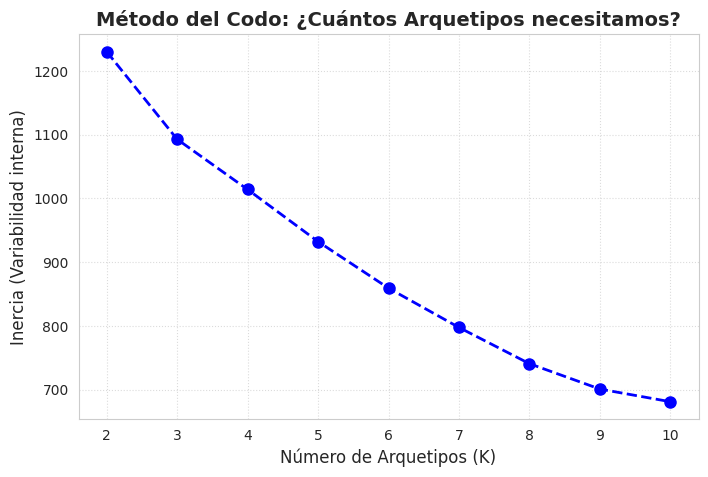

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Preparando datos, escalando y calculando el Método del Codo.")

# Cargamos el CSV
df_arquetipos = pd.read_csv('clusters_cdmx.csv')

# Ingeniería de Características
columnas_sectores = [f'sector_{i}' for i in range(1, 8)]
for col in columnas_sectores:
    df_arquetipos[f'pct_{col}'] = (df_arquetipos[col] / df_arquetipos['total_negocios']) * 100

variables_modelo = ['trafico_total', 'rating_promedio', 'tasa_actividad'] + [f'pct_{col}' for col in columnas_sectores]
df_modelo = df_arquetipos[variables_modelo].fillna(0)

# Escalamos
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_modelo)

# Calculamos las inercias para el codo
inercias = []
rango_k = range(2, 11) # Probamos de 2 a 10 arquetipos

for k in rango_k:
    modelo_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    modelo_prueba.fit(datos_escalados)
    inercias.append(modelo_prueba.inertia_)

# Dibujamos la gráfica
plt.figure(figsize=(8, 5))
plt.plot(rango_k, inercias, marker='o', linestyle='--', color='b', linewidth=2, markersize=8)
plt.title('Método del Codo: ¿Cuántos Arquetipos necesitamos?', fontsize=14, fontweight='bold')
plt.xlabel('Número de Arquetipos (K)', fontsize=12)
plt.ylabel('Inercia (Variabilidad interna)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Calculando la calidad de separación (Coeficiente de Silueta)...


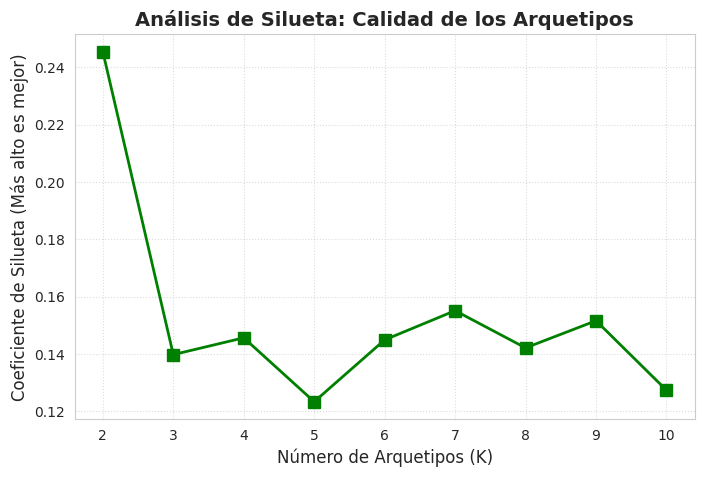

In [10]:
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

print("Calculando la calidad de separación (Coeficiente de Silueta)...")

siluetas = []
rango_k = range(2, 11) # Probamos los mismos grupos que en el codo

for k in rango_k:
    modelo_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    # Aquí fit_predict entrena y nos da las etiquetas al mismo tiempo
    etiquetas = modelo_prueba.fit_predict(datos_escalados)

    # Calculamos la calificación de la silueta para este K
    score = silhouette_score(datos_escalados, etiquetas)
    siluetas.append(score)

# Dibujamos la gráfica
plt.figure(figsize=(8, 5))
plt.plot(rango_k, siluetas, marker='s', linestyle='-', color='g', linewidth=2, markersize=8)
plt.title('Análisis de Silueta: Calidad de los Arquetipos', fontsize=14, fontweight='bold')
plt.xlabel('Número de Arquetipos (K)', fontsize=12)
plt.ylabel('Coeficiente de Silueta (Más alto es mejor)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

Índice de Davies-Bouldin para seguir viendo qué K con conviene.


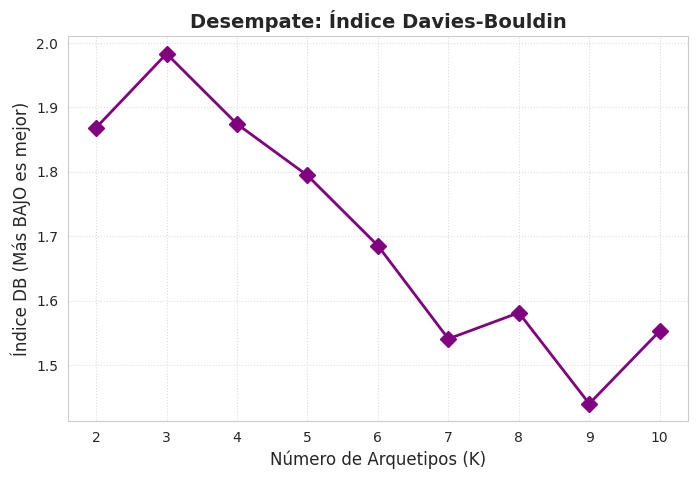

In [11]:
from sklearn.metrics import davies_bouldin_score

print("Índice de Davies-Bouldin para seguir viendo qué K con conviene.")

davies = []
rango_k = range(2, 11)

for k in rango_k:
    modelo_prueba = KMeans(n_clusters=k, random_state=42, n_init=10)
    etiquetas = modelo_prueba.fit_predict(datos_escalados)

    # Calculamos Davies-Bouldin (buscar el punto más bajo)
    score = davies_bouldin_score(datos_escalados, etiquetas)
    davies.append(score)

# Dibujamos la gráfica
plt.figure(figsize=(8, 5))
plt.plot(rango_k, davies, marker='D', linestyle='-', color='purple', linewidth=2, markersize=8)
plt.title('Desempate: Índice Davies-Bouldin', fontsize=14, fontweight='bold')
plt.xlabel('Número de Arquetipos (K)', fontsize=12)
plt.ylabel('Índice DB (Más BAJO es mejor)', fontsize=12)
plt.xticks(rango_k)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

### Selección Definitiva de Hiperparámetros (Justificación de $K=9$)

#### Contexto del Dilema de Selección

1. **Coeficiente de Silueta** sugirió $K=2$, penalizando la complejidad y buscando la partición de menor riesgo
2. **Método del Codo** mostró un cambio en $K=3$, capturando la variabilidad gruesa de los datos.
3. **Índice de Davies-Bouldin** alcanzó su punto mínimo en $K=9$.

Se toma la decisión de adoptar **$K=9$ Arquetipos** basándose en:

#### Criterio de Minimización de Davies-Bouldin
El índice de Davies-Bouldin evalúa la similitud entre clusters basándose en la relación de sus distancias intra-cluster (dispersión interna) frente a sus distancias inter-cluster (separación).

#### Evitación del Fenómeno de Subajuste (Underfitting) Comercial
Reducir el espacio económico del sur de la CDMX a solo 2 o 3 categorías generaría un subajuste analítico. En el urbanismo comercial, un modelo con $K=3$ se limitaría a clasificar los polígonos de forma genérica.

#### Optimización del Motor de Recomendaciones (Valor de Negocio)
Un sistema de recomendación de inversiones requiere granularidad para ser accionable. Para un inversionista o analista de BI, un modelo con 9 arquetipos ofrece un mapa de decisiones mucho más preciso, permitiendo identificar oferta y ventanas de oportunidad con un nivel de detalle que un modelo rezagado en $K=3$ diluiría en sus promedios.

Ejecutando Meta-Clustering con K=9
Se detectaron 9 Micro-Nichos de Negocio distintos.

              trafico_total  rating_promedio  tasa_actividad  pct_sector_1  pct_sector_2  pct_sector_3  pct_sector_4  pct_sector_5  pct_sector_6  pct_sector_7
id_arquetipo                                                                                                                                                  
0                    3627.7              4.3            85.5          62.0          10.2          10.5           0.1           1.5           3.1          12.6
1                   22587.6              4.2            92.4          39.7          16.1          22.4           5.1           2.1           4.5          10.0
2                   71159.1              3.9            92.8          24.8          35.4          16.0           1.3           6.8           3.5          12.2
3                    9775.5              4.3            91.5          23.1          17.2          19.8           0.7  

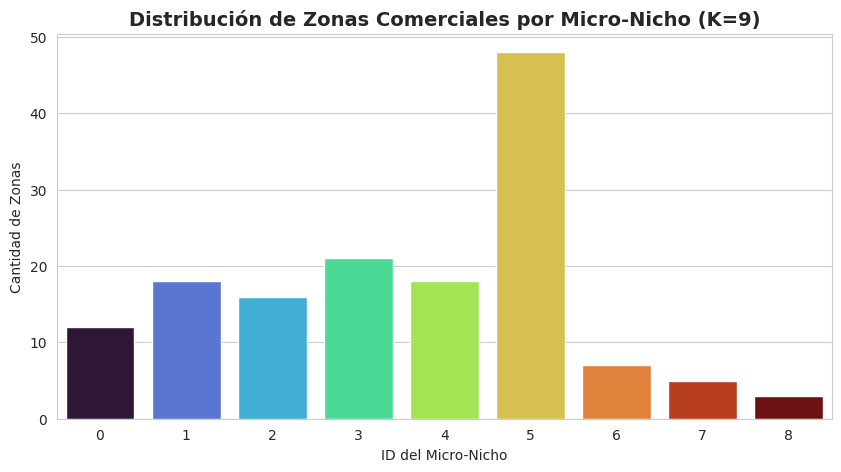

Archivo guardado como 'meta_clustering_cdmx.csv'


In [12]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

print("Ejecutando Meta-Clustering con K=9")

# Cargamos el cluster previo
df_arquetipos = pd.read_csv('clusters_cdmx.csv')

# Ingeniería de Características
columnas_sectores = [f'sector_{i}' for i in range(1, 8)]
for col in columnas_sectores:
    df_arquetipos[f'pct_{col}'] = (df_arquetipos[col] / df_arquetipos['total_negocios']) * 100

variables_modelo = ['trafico_total', 'rating_promedio', 'tasa_actividad'] + [f'pct_{col}' for col in columnas_sectores]
df_modelo = df_arquetipos[variables_modelo].fillna(0)

# Escalamos
scaler = StandardScaler()
datos_escalados = scaler.fit_transform(df_modelo)

# Entrenamiento de K-Means
K = 9
kmeans = KMeans(n_clusters=K, random_state=42, n_init=10)
df_arquetipos['id_arquetipo'] = kmeans.fit_predict(datos_escalados)

# Análisis de los 9 Arquetipos
perfil_arquetipos = df_arquetipos.groupby('id_arquetipo')[variables_modelo].mean().round(1)

print(f"Se detectaron {K} Micro-Nichos de Negocio distintos.\n")
# Mostramos todas las columnas de sectores para ver exactamente en qué se especializa cada uno
print(perfil_arquetipos.to_string())

# Gráfica de distribución
plt.figure(figsize=(10, 5))
sns.countplot(data=df_arquetipos, x='id_arquetipo', palette='turbo', hue='id_arquetipo', legend=False)
plt.title('Distribución de Zonas Comerciales por Micro-Nicho (K=9)', fontsize=14, fontweight='bold')
plt.xlabel('ID del Micro-Nicho')
plt.ylabel('Cantidad de Zonas')
plt.show()

# 7. Guardamos la base como versión K9
df_arquetipos.to_csv('meta_clustering_cdmx.csv', index=False)
print("Archivo guardado como 'meta_clustering_cdmx.csv'")

In [13]:
import pandas as pd

print("Traducción de sectores.\n")

# Cargamos tu catálogo de macrosectores y armamos un diccionario
df_macro = pd.read_csv('cat_macrosectores.csv')
diccionario_sectores = dict(zip(df_macro['id_macro'], df_macro['nombre_macro']))

# Cargamos el meta cluster
df_final = pd.read_csv('meta_clustering_cdmx.csv')

# Calculamos los promedios de los 9 grupos
columnas_pct = [f'pct_sector_{i}' for i in range(1, 8)]
variables = ['trafico_total', 'rating_promedio', 'tasa_actividad'] + columnas_pct

promedios = df_final.groupby('id_arquetipo')[variables].mean().round(1)

# Cambiamos "pct_sector_1" por su nombre real
renombres = {f'pct_sector_{i}': f'% {nombre.title()}' for i, nombre in diccionario_sectores.items()}
promedios = promedios.rename(columns=renombres)

# Renombramos también las otras para que quede impecable
promedios = promedios.rename(columns={
    'trafico_total': 'Tráfico Promedio',
    'rating_promedio': 'Rating Prom.',
    'tasa_actividad': 'Actividad (%)'
})

print("MICRO-NICHOS:")
print("-" * 100)
# Mostramos la tabla transpuesta (.T) para que sea súper fácil de leer si son muchas columnas
print(promedios.T.to_string())
print("-" * 100)

Traducción de sectores.

MICRO-NICHOS:
----------------------------------------------------------------------------------------------------
id_arquetipo                      0        1        2       3       4        5       6       7         8
Tráfico Promedio             3627.7  22587.6  71159.1  9775.5  8388.8  14065.1  6035.1  7992.6  334628.3
Rating Prom.                    4.3      4.2      3.9     4.3     4.2      4.4     4.2     4.1       4.1
Actividad (%)                  85.5     92.4     92.8    91.5    85.7     90.9    92.4    92.6      92.7
% Alimentos Y Bebidas          62.0     39.7     24.8    23.1    23.0     37.5    20.7    16.2      27.9
% Retail Y Conveniencia        10.2     16.1     35.4    17.2    25.3     16.1    20.1    16.4      36.7
% Salud Y Bienestar            10.5     22.4     16.0    19.8    30.9     21.9    17.8    32.8      13.3
% Entretenimiento               0.1      5.1      1.3     0.7     0.4      1.0     0.9     0.5       2.5
% Finanzas Y Servici

In [15]:
import pandas as pd

print("Generando el catálogo de Arquetipos.")

datos_catalogo = {
    'id_arquetipo': list(range(9)),
    'Nombre_Arquetipo': [
        'Cluster Gastronomico',
        'Corredor Mixto (Comida y Bienestar)',
        'Area de Mejora',
        'Zona Especializada en Servicios/Mantenimiento',
        'Medico y Farmaceutico',
        'Ecosistema Comercial de Alta Satisfacción',
        'Cluster Educativo y Escolar',
        'Corredor de Salud y Finanzas',
        'Epicentro Comercial y Tráfico Masivo'
    ],
    'Descripcion_Estrategica': [
        'Zonas de bajo tráfico peatonal pero altísima concentración (62%) de giros de alimentos y bebidas. Ideal para dark kitchens o restaurantes de destino.',
        'Ecosistemas equilibrados con alto nivel de actividad (92%), liderados por la oferta gastronómica y servicios de salud/cuidado personal.',
        'Zonas de alto tránsito (71k) dominadas por el retail (35%), pero que presentan el rating de satisfacción más bajo (3.9). Oportunidad de competir con calidad.',
        'Sectores altamente especializados donde casi el 35% de la oferta se centra en reparaciones, oficios y mantenimiento. Tráfico local/vecinal.',
        'Polígonos concentrados en salud y farmacias (31%), acompañados de retail. Presentan ligera vulnerabilidad con tasas de actividad del 85%.',
        'Zonas destacadas por tener la mejor reputación y satisfacción del cliente (Rating 4.4). Combinan alimentos, salud y servicios de alta calidad.',
        'Zonas impulsadas por la vida académica. Poseen la mayor concentración de giros educativos (18%), rodeados de retail y servicios afines.',
        'Corredores de trámites y cuidado. Lideran en servicios de salud (32%) y albergan la mayor presencia de instituciones financieras (12%).',
        'Los gigantes de la CDMX. Zonas con tráfico peatonal colosal (+300k), donde convergen masivamente el retail (36%) y los alimentos (27%).'
    ]
}

df_cat_arquetipos = pd.DataFrame(datos_catalogo)
df_cat_arquetipos.to_csv('cat_arquetipos_mc.csv', index=False)

print("Catálogo 'cat_arquetipos_mc.csv' creado con éxito")

Generando el catálogo de Arquetipos.
Catálogo 'cat_arquetipos_mc.csv' creado con éxito
